In [17]:
from pathlib import Path
import sys
from datetime import datetime
import os
import joblib

ROOT_DIR = Path.cwd().parent.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
print(f'Base directory -> {ROOT_DIR}')

from config.settings import (
    DATA_DIR,
    MODELS_DIR
)

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

Base directory -> /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


In [2]:
master = pd.read_csv(f'{DATA_DIR}/master.csv')
master['sale_date'] = pd.to_datetime(master['sale_date'])
master = master.set_index('sale_date')
master

,net_price,non_work_day,is_month_end,close_month_zone
sale_date,,,,
2024-01-02,"719,422.63",0,0,0
2024-01-03,"992,292.59",0,0,0
2024-01-04,"802,011.48",0,0,0
2024-01-05,"484,853.02",0,0,0
2024-01-06,"60,058.17",0,0,0
...,...,...,...,...
2026-05-11,"1,790,415.58",0,0,0
2026-05-12,"2,139,962.69",0,0,0
2026-05-13,"1,245,428.49",0,0,1


In [3]:
#generacion de lags
master['lag_1'] = master['net_price'].shift(1)
master['lag_7'] = master['net_price'].shift(7)

#eliminacion de nulos porque los primeros datos no tienen lags
master = master.dropna()

master

,net_price,non_work_day,is_month_end,close_month_zone,lag_1,lag_7
sale_date,,,,,,
2024-01-09,"1,082,699.55",0,0,0,"622,816.98","719,422.63"
2024-01-10,"797,017.78",0,0,0,"1,082,699.55","992,292.59"
2024-01-11,"611,524.10",0,0,0,"797,017.78","802,011.48"
2024-01-12,"826,546.08",0,0,0,"611,524.10","484,853.02"
2024-01-13,0.00,0,0,0,"826,546.08","60,058.17"
...,...,...,...,...,...,...
2026-05-11,"1,790,415.58",0,0,0,0.00,"1,937,861.36"
2026-05-12,"2,139,962.69",0,0,0,"1,790,415.58","1,300,311.08"
2026-05-13,"1,245,428.49",0,0,1,"2,139,962.69","997,436.80"


In [4]:
#definicion de y y X
features = ['lag_1', 'lag_7', 'non_work_day', 'is_month_end', 'close_month_zone']
target = ['net_price']

#definicion de rangos de entreamiento y pruebas
train_cutoff = '2026-03-31'
validation_start = '2026-04-01'
validation_end = '2026-04-30'

In [5]:
#split de datos
X_train_raw = master.loc[:train_cutoff, features]
y_train_raw = master.loc[:train_cutoff, target]

display(X_train_raw)

display(y_train_raw)

,lag_1,lag_7,non_work_day,is_month_end,close_month_zone
sale_date,,,,,
2024-01-09,"622,816.98","719,422.63",0,0,0
2024-01-10,"1,082,699.55","992,292.59",0,0,0
2024-01-11,"797,017.78","802,011.48",0,0,0
2024-01-12,"611,524.10","484,853.02",0,0,0
2024-01-13,"826,546.08","60,058.17",0,0,0
...,...,...,...,...,...
2026-03-27,"1,680,637.42","1,320,038.51",0,0,1
2026-03-28,"1,237,289.26",0.00,0,0,0
2026-03-29,0.00,0.00,0,0,0


,net_price
sale_date,
2024-01-09,"1,082,699.55"
2024-01-10,"797,017.78"
2024-01-11,"611,524.10"
2024-01-12,"826,546.08"
2024-01-13,0.00
...,...
2026-03-27,"1,237,289.26"
2026-03-28,0.00
2026-03-29,0.00


In [6]:
X_test_raw = master.loc[validation_start:validation_end, features]
y_test_raw = master.loc[validation_start:validation_end, target]

display(X_test_raw)


display(y_test_raw)

,lag_1,lag_7,non_work_day,is_month_end,close_month_zone
sale_date,,,,,
2026-04-01,"2,964,747.97","1,216,806.19",0,0,0
2026-04-02,"1,417,995.00","1,680,637.42",1,0,0
2026-04-03,0.00,"1,237,289.26",1,0,0
2026-04-04,0.00,0.00,0,0,0
2026-04-05,0.00,0.00,0,0,0
2026-04-06,0.00,"2,718,817.07",0,0,0
2026-04-07,"2,877,655.05","2,964,747.97",0,0,0
2026-04-08,"1,780,346.37","1,417,995.00",0,0,0
2026-04-09,"1,674,429.51",0.00,0,0,0


,net_price
sale_date,
2026-04-01,"1,417,995.00"
2026-04-02,0.00
2026-04-03,0.00
2026-04-04,0.00
2026-04-05,0.00
2026-04-06,"2,877,655.05"
2026-04-07,"1,780,346.37"
2026-04-08,"1,674,429.51"
2026-04-09,"1,741,267.80"


La idea general de esta red será crear 3 escaladores diferentes, $StandardScaler$, $RobustScaler$ y $MinMaxScaler$.

Se tomó esta decisión debido a que, por el funcionamiento interno de la red LSTM y que usa activaciones por sigmoide o que están en rangos definidos, los outliers si pueden afectar la capacidad de disernir variaciones sutiles, limitando la capacidad de predicciones.

Se creará un bucle for que pruebe 

In [9]:
#establecemos los escaladores a usar en un diccionario
scalers_to_test = {
    "MinMaxScaler": (MinMaxScaler(feature_range=(0, 1)), MinMaxScaler(feature_range=(0, 1))),
    "StandardScaler": (StandardScaler(), StandardScaler()),
    "RobustScaler": (RobustScaler(), RobustScaler())
}

In [11]:
#variables para rastrear el mejor desempeño
best_score = float('inf') #este score indicará la mejor relacion entre wmape y tpd
best_wape = float('inf') #inidca el error real acumulado por prediccion dado un forecast
best_tpd = float('inf') #total percentage difference, o diferencia porcentual total, es decir, se suman las predicciones individuales, se comparan con el valor real y se saca el porcentaje de error total
best_scaler_name = None
best_preds = None

In [12]:
#definición del directorio donde se guardarán los pesos, en caso de que el directporio no exista, se crea automaticamente
lstm_dir = os.path.join(MODELS_DIR, "lstm")
os.makedirs(lstm_dir, exist_ok=True)

In [19]:
for name, (scaler_x, scaler_y) in scalers_to_test.items():
    print(f'\n\nevaluación de {name}')

    #escalamiento de los datos de entrenamiento
    X_train_scaled = scaler_x.fit_transform(X_train_raw)
    y_train_scaled = scaler_y.fit_transform(y_train_raw)

    #escalamiento de los datos de validación
    X_test_scaled = scaler_x.transform(X_test_raw)
    y_test_scaled = scaler_y.transform(y_test_raw)

    #reestablecimiento de la forma ya que tensorflow recibe de la forma (n_muestras, timesteps, n_features)
    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))
    
    #seteo de la estructura del modelo
    model = Sequential([
        LSTM(units=50, activation='relu', return_sequences=True, 
             input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])), #50 neuronas
        Dropout(0.2),
        LSTM(units=50, activation='relu'), #50 neuronas
        Dropout(0.2),
        Dense(units=1) #solo una de salida
    ])

    model.compile(optimizer='adam', loss='mse')

    #entrenamiento del modelo
    history = model.fit(
        X_train_lstm,
        y_train_scaled,
        epochs=25,
        batch_size=32,
        validation_data=(X_test_lstm, y_test_scaled),
        verbose=0, 
        shuffle=False
    )


    # generacion de predicciones y desescalamiento
    pred_scaled = model.predict(X_test_lstm, verbose=0)
    predicciones_lstm = scaler_y.inverse_transform(pred_scaled)

    real_array = y_test_raw.values.flatten()
    pred_array = predicciones_lstm.flatten()

    print('\nmetricas obtenidas')
    wape_puro = (np.sum(np.abs(real_array - pred_array)) / np.sum(real_array)) * 100
    tpd = ((pred_array.sum() - real_array.sum()) / real_array.sum()) * 100

    print(f'WMAPE {name}: {wape_puro:.2f} %')
    print(f'TPD {name}: {tpd:.2} %')

    #la relación será calculada como la suma de ambos valores. un valor cercano a cero indica un mejor rendimiento
    #la relación entre ambos da mas importancia a la proyección macro que a la micro
    combined_score = (0.30 * wape_puro) + (0.70 * np.abs(tpd))

    print(f'Score {name}: {combined_score:.2f}')

    #evaluación del mejor modelo para guardar
    if combined_score < best_score:
        best_score = combined_score
        best_wape = wape_puro
        best_tpd = tpd
        best_scaler_name = name
        best_preds = pred_array
        
        #guardar el modelo en formato nativo Keras
        model.save(os.path.join(lstm_dir, "best_lstm_model.keras"))
        
        #guardar los escaladores asociados al modelo ganador
        joblib.dump(scaler_x, os.path.join(lstm_dir, "scaler_x.pkl"))
        joblib.dump(scaler_y, os.path.join(lstm_dir, "scaler_y.pkl"))

        history_df = pd.DataFrame(history.history)
        history_df.to_csv(os.path.join(lstm_dir, "history_ganador.csv"), index=False)



print(f"\n\n\n scaler seleccionado -> {best_scaler_name}")
print(f"score combinado optimo -> {best_score:.2f}")
print(f"WMAPE obtenido -> {best_wape:.2f}%")
print(f"Diferencia Porcentual Mensual -> {best_tpd:.2f}%")



evaluación de MinMaxScaler


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



metricas obtenidas
WMAPE MinMaxScaler: 30.59 %
TPD MinMaxScaler: -1.3e+01 %
Score MinMaxScaler: 18.31


evaluación de StandardScaler


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



metricas obtenidas
WMAPE StandardScaler: 31.48 %
TPD StandardScaler: -1.9e+01 %
Score StandardScaler: 22.79


evaluación de RobustScaler


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



metricas obtenidas
WMAPE RobustScaler: 31.53 %
TPD RobustScaler: -1.6e+01 %
Score RobustScaler: 20.43



 scaler seleccionado -> MinMaxScaler
score combinado optimo -> 18.31
WMAPE obtenido -> 30.59%
Diferencia Porcentual Mensual -> -13.05%


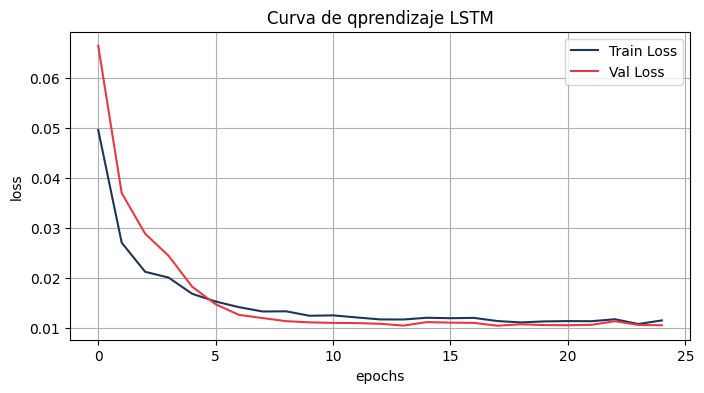

In [22]:
history_log = pd.read_csv(os.path.join(lstm_dir, "history_ganador.csv"))

plt.figure(figsize=(8, 4))
plt.plot(history_log['loss'], label='Train Loss', color='#1d3557')
plt.plot(history_log['val_loss'], label='Val Loss', color='#e63946')
plt.title('Curva de qprendizaje LSTM')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
real_array = y_test_raw.values.flatten()
pred_array = best_preds

#desviaciones y errores globales
error = np.abs(real_array - pred_array)
wape_puro = (np.sum(error) / np.sum(real_array)) * 100
diferencia_total_porcentual = ((pred_array.sum() - real_array.sum()) / real_array.sum()) * 100

print(f"Suma real total abril: {real_array.sum():,.2f}")
print(f"Suma pred total abril: {pred_array.sum():,.2f}")
print(f'Error acumulado abril: {error.sum():,.2f}')
print(f'Diff real: {real_array.sum() - pred_array.sum():,.2f}')
print(f"Diff total porcentual mensual: {diferencia_total_porcentual:.2f}%")
print(f"WMAPE total abril: {wape_puro:.2f}%")

Suma real total abril: 34,292,377.81
Suma pred total abril: 29,816,638.00
Error acumulado abril: 10,489,899.89
Diff real: 4,475,739.81
Diff total porcentual mensual: -13.05%
WMAPE total abril: 30.59%


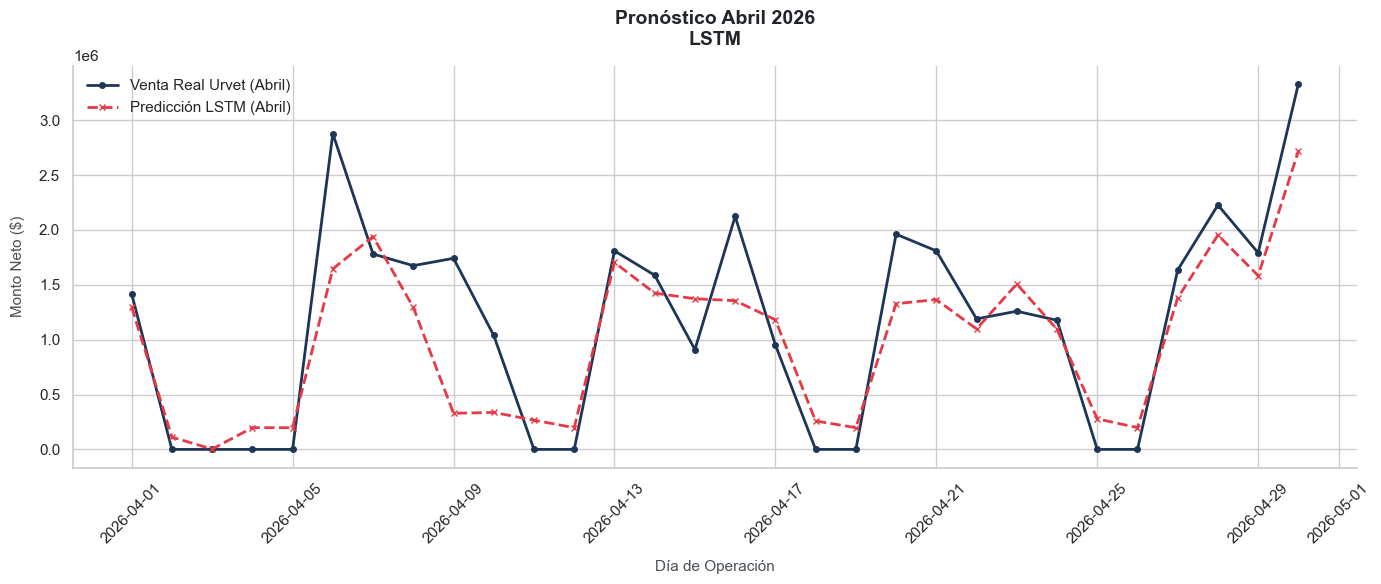

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6), dpi=100)

plt.plot(y_test_raw.index, real_array, marker='o', markersize=4, color='#1d3557', 
         linewidth=2, label='Venta Real Urvet (Abril)')
plt.plot(y_test_raw.index, pred_array, marker='x', markersize=4, color='#e63946', 
         linewidth=2, linestyle='--', label='Predicción LSTM (Abril)')

plt.title('Pronóstico Abril 2026\nLSTM', fontsize=14, pad=15, fontweight='bold', color='#212529')
plt.xlabel('Día de Operación', fontsize=11, labelpad=10, color='#495057')
plt.ylabel('Monto Neto ($)', fontsize=11, labelpad=10, color='#495057')

plt.xticks(rotation=45)
plt.legend(loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()